# 06 Evaluation Expansion (Week 8)

This notebook completes the Week 8 evaluation task by consolidating model results across weeks, comparing metrics beyond `R2`, and summarizing model behavior by price band.

## Week 8 Goal

The Week 8 requirement is to expand evaluation beyond `R2` by reporting `MAPE` and `MdAPE`, then summarize where the models perform better or worse.

This notebook does not train a new model. Instead, it reads the saved outputs from earlier notebooks and creates a unified evaluation summary.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

output_dir = Path("../outputs")
print(f"Output directory: {output_dir.resolve()}")

Output directory: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs


## Load Saved Model Results

The evaluation summary combines the strongest or most relevant model outputs from Week 4, Week 5, Week 6, and Week 7.

In [2]:
required_files = {
    "week5": output_dir / "week5_model_comparison_results.csv",
    "week6": output_dir / "week6_feature_engineering_results.csv",
    "week7": output_dir / "week7_advanced_model_results.csv",
    "week7_predictions": output_dir / "week7_best_advanced_predictions.csv",
    "week7_segments": output_dir / "week7_price_segment_results.csv",
    "week7_sanity": output_dir / "week7_prediction_sanity_checks.csv",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required output files: {missing_files}")

week5_results = pd.read_csv(required_files["week5"])
week6_results = pd.read_csv(required_files["week6"])
week7_results = pd.read_csv(required_files["week7"])
week7_predictions = pd.read_csv(required_files["week7_predictions"])
week7_segments = pd.read_csv(required_files["week7_segments"])
week7_sanity = pd.read_csv(required_files["week7_sanity"])

print("Loaded saved result files.")
display(week7_results.head())

Loaded saved result files.


,model_name,MAE,RMSE,R2,MAPE,MdAPE,feature_set,filtered_training,feature_count,train_rows,max_depth,learning_rate,n_estimators,min_child_weight,min_prediction,max_prediction,predictions_over_50m
0,LinearRegression,176033.5133,1009587.8902,0.6372,0.1953,0.0825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgb_log_market_context_all,75748.9291,1013238.9295,0.6345,0.0724,0.0251,market_context,False,28.0000,59505.0000,3.0000,0.0300,600.0000,15.0000,72940.5312,26379218.0000,0.0000
2,xgb_log_reality_all,75476.9368,1013314.4238,0.6345,0.0728,0.0253,reality,False,23.0000,59505.0000,3.0000,0.0300,600.0000,15.0000,67936.2578,25502302.0000,0.0000
3,xgb_log_market_context_filtered,76023.7264,1031333.8922,0.6214,0.0720,0.0243,market_context,True,28.0000,59390.0000,3.0000,0.0500,450.0000,25.0000,111449.8359,18026948.0000,0.0000
4,xgb_log_baseline_all,82620.9954,1043080.7636,0.6127,0.0741,0.0262,baseline,False,13.0000,59505.0000,3.0000,0.0500,450.0000,25.0000,81742.9453,18564736.0000,0.0000


## Build Metrics Summary

This table is the main Week 8 deliverable. It standardizes the model results into one comparison table with `R2`, `MAPE`, `MdAPE`, `MAE`, and `RMSE`.

In [3]:
summary_rows = []

for _, row in week5_results.iterrows():
    summary_rows.append(
        {
            "week": "Week 5",
            "model_name": row["model_name"],
            "model_family": row["model_name"],
            "feature_set": "retained_baseline_features",
            "R2": row["R2"],
            "MAPE": row["MAPE"],
            "MdAPE": row["MdAPE"],
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "note": "Week 5 model comparison on the same holdout month",
        }
    )

for _, row in week6_results.iterrows():
    summary_rows.append(
        {
            "week": "Week 6",
            "model_name": row["model_name"],
            "model_family": "LinearRegression",
            "feature_set": row["model_name"],
            "R2": row["R2"],
            "MAPE": row["MAPE"],
            "MdAPE": row["MdAPE"],
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "note": "Week 6 feature-engineering comparison",
        }
    )

for _, row in week7_results.iterrows():
    model_family = (
        "LinearRegression" if row["model_name"] == "LinearRegression" else "XGBoost"
    )
    summary_rows.append(
        {
            "week": "Week 7",
            "model_name": row["model_name"],
            "model_family": model_family,
            "feature_set": row.get("feature_set", ""),
            "R2": row["R2"],
            "MAPE": row["MAPE"],
            "MdAPE": row["MdAPE"],
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "note": "Week 7 advanced-model comparison",
        }
    )

metrics_summary = pd.DataFrame(summary_rows)
metric_cols = ["R2", "MAPE", "MdAPE", "MAE", "RMSE"]
metrics_summary[metric_cols] = metrics_summary[metric_cols].apply(
    pd.to_numeric, errors="coerce"
)

metrics_summary = metrics_summary.sort_values(
    ["MAPE", "MdAPE", "R2"], ascending=[True, True, False]
).reset_index(drop=True)

display(metrics_summary)

,week,model_name,model_family,feature_set,R2,MAPE,MdAPE,MAE,RMSE,note
0,Week 7,xgb_log_market_context_filtered,XGBoost,market_context,0.6214,0.0720,0.0243,76023.7264,1031333.8922,Week 7 advanced-model comparison
1,Week 7,xgb_log_market_context_all,XGBoost,market_context,0.6345,0.0724,0.0251,75748.9291,1013238.9295,Week 7 advanced-model comparison
2,Week 7,xgb_log_reality_all,XGBoost,reality,0.6345,0.0728,0.0253,75476.9368,1013314.4238,Week 7 advanced-model comparison
3,Week 7,xgb_log_baseline_all,XGBoost,baseline,0.6127,0.0741,0.0262,82620.9954,1043080.7636,Week 7 advanced-model comparison
4,Week 6,baseline_features,LinearRegression,baseline_features,0.6372,0.1952,0.0823,175982.7300,1009587.5800,Week 6 feature-engineering comparison
5,Week 7,LinearRegression,LinearRegression,NaN,0.6372,0.1953,0.0825,176033.5133,1009587.8902,Week 7 advanced-model comparison
6,Week 5,LinearRegression,LinearRegression,retained_baseline_features,0.6371,0.1954,0.0824,176134.1128,1010179.0950,Week 5 model comparison on the same holdout month
7,Week 6,compact_engineered_features,LinearRegression,compact_engineered_features,0.6359,0.2074,0.0892,185062.6100,1011356.2200,Week 6 feature-engineering comparison
8,Week 6,district_swap_features,LinearRegression,district_swap_features,0.5742,0.2290,0.0685,187473.7100,1093699.7400,Week 6 feature-engineering comparison
9,Week 5,DecisionTree,DecisionTree,retained_baseline_features,0.3805,0.2299,0.0665,202766.8782,1319878.0053,Week 5 model comparison on the same holdout month


In [4]:
metrics_summary_path = output_dir / "metrics_summary.csv"
metrics_summary.to_csv(metrics_summary_path, index=False)
print(f"Saved metrics summary to {metrics_summary_path}")

Saved metrics summary to ../outputs/metrics_summary.csv


## Overall Model Comparison

`R2` measures overall explained variance, while `MAPE` and `MdAPE` measure percentage error. For a pricing task, percentage error is often easier to interpret because a $50,000 error means something different for a $300,000 home than for a $3,000,000 home.

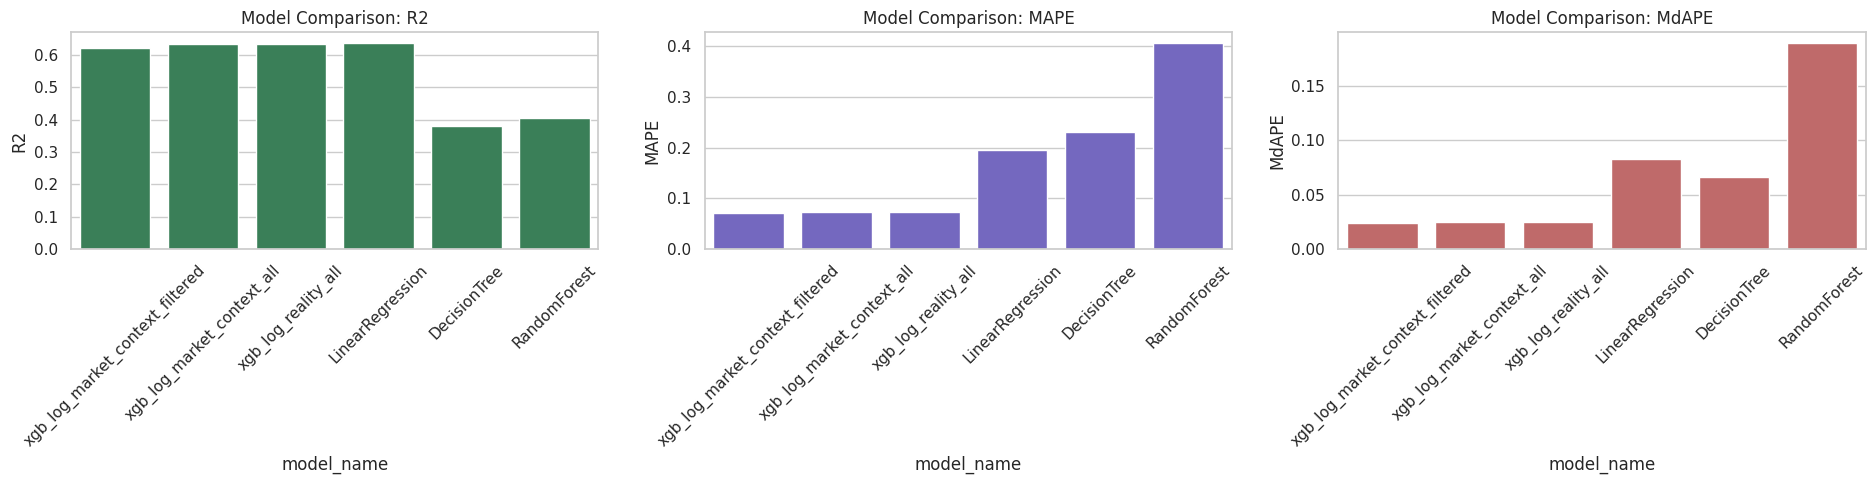

In [5]:
plot_models = metrics_summary.loc[
    metrics_summary["model_name"].isin(
        [
            "LinearRegression",
            "DecisionTree",
            "RandomForest",
            "xgb_log_market_context_all",
            "xgb_log_reality_all",
            "xgb_log_market_context_filtered",
        ]
    )
].copy()

plot_models = plot_models.drop_duplicates(subset=["model_name"], keep="first")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(data=plot_models, x="model_name", y="R2", ax=axes[0], color="seagreen")
axes[0].set_title("Model Comparison: R2")
axes[0].set_ylabel("R2")

sns.barplot(data=plot_models, x="model_name", y="MAPE", ax=axes[1], color="slateblue")
axes[1].set_title("Model Comparison: MAPE")
axes[1].set_ylabel("MAPE")

sns.barplot(data=plot_models, x="model_name", y="MdAPE", ax=axes[2], color="indianred")
axes[2].set_title("Model Comparison: MdAPE")
axes[2].set_ylabel("MdAPE")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Best Model Tradeoff

The strongest linear model and the best XGBoost model tell slightly different stories. Linear Regression remains strong on `R2`, but XGBoost produces much lower percentage errors for most properties.

,model_name,R2,MAPE,MdAPE,MAE
0,LinearRegression,0.6372,0.1953,0.0825,176033.5133
1,xgb_log_market_context_filtered,0.6214,0.0720,0.0243,76023.7264


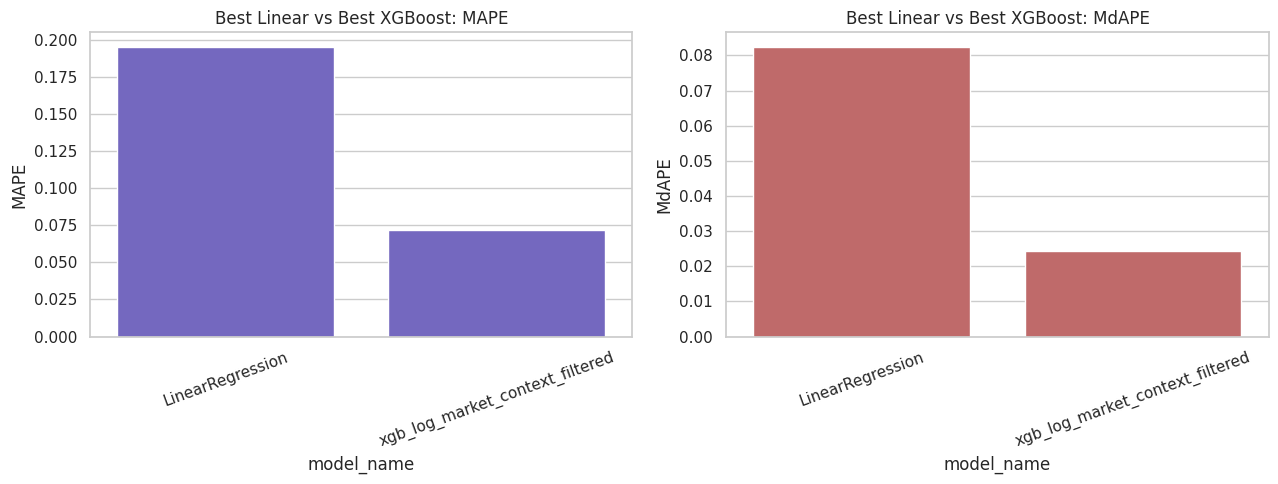

In [6]:
best_linear = week7_results[week7_results["model_name"] == "LinearRegression"].iloc[0]
best_xgb = (
    week7_results[week7_results["model_name"] != "LinearRegression"]
    .sort_values(["MAPE", "MdAPE", "R2"], ascending=[True, True, False])
    .iloc[0]
)

tradeoff_df = pd.DataFrame(
    [
        {
            "model_name": "LinearRegression",
            "R2": best_linear["R2"],
            "MAPE": best_linear["MAPE"],
            "MdAPE": best_linear["MdAPE"],
            "MAE": best_linear["MAE"],
        },
        {
            "model_name": best_xgb["model_name"],
            "R2": best_xgb["R2"],
            "MAPE": best_xgb["MAPE"],
            "MdAPE": best_xgb["MdAPE"],
            "MAE": best_xgb["MAE"],
        },
    ]
)

for col in ["R2", "MAPE", "MdAPE", "MAE"]:
    tradeoff_df[col] = pd.to_numeric(tradeoff_df[col], errors="coerce")

display(tradeoff_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=tradeoff_df, x="model_name", y="MAPE", ax=axes[0], color="slateblue")
axes[0].set_title("Best Linear vs Best XGBoost: MAPE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=tradeoff_df, x="model_name", y="MdAPE", ax=axes[1], color="indianred")
axes[1].set_title("Best Linear vs Best XGBoost: MdAPE")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Price Band Evaluation

This is the main Week 8 insight section. It shows which price ranges perform better and where the model still struggles.

,price_segment,row_count,linear_mape,advanced_mape,linear_mdape,advanced_mdape
0,<$300k,279,1.8523,1.4930,0.2705,0.0490
1,$300k-$500k,1419,0.2044,0.0357,0.1711,0.0217
2,$500k-$1M,4897,0.1894,0.0320,0.0969,0.0214
3,$1M-$3M,4686,0.1175,0.0422,0.0512,0.0288
4,$3M+,740,0.0842,0.0653,0.0678,0.0421


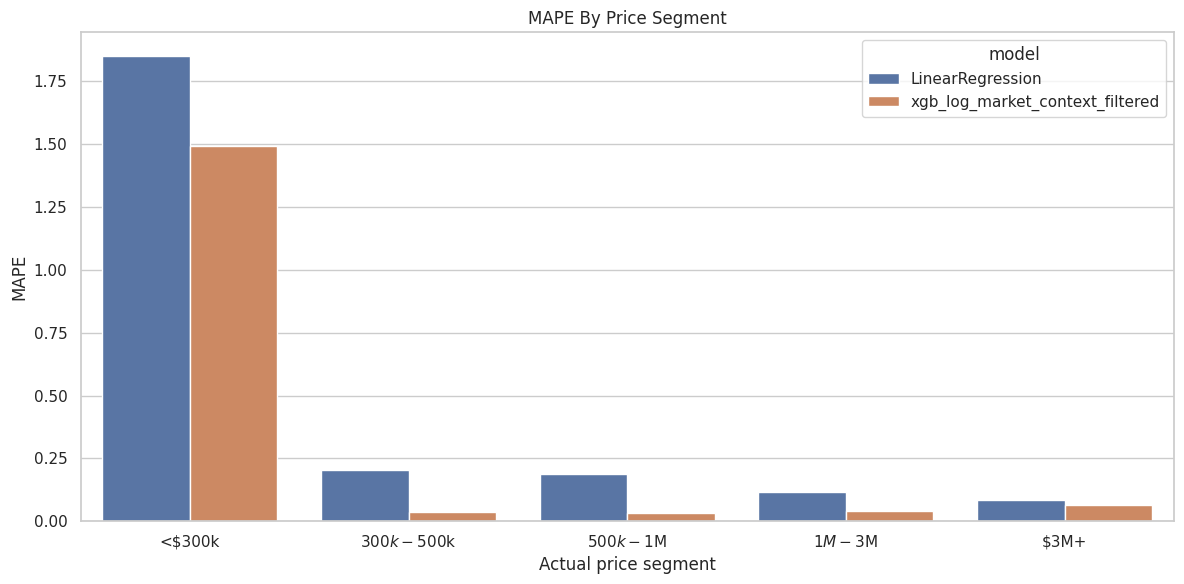

Saved price band summary to ../outputs/price_band_summary.csv


In [7]:
price_band_summary = week7_segments.copy()
display(price_band_summary)

price_band_plot = price_band_summary.melt(
    id_vars=["price_segment", "row_count"],
    value_vars=["linear_mape", "advanced_mape"],
    var_name="model",
    value_name="MAPE",
)
price_band_plot["model"] = price_band_plot["model"].replace(
    {"linear_mape": "LinearRegression", "advanced_mape": best_xgb["model_name"]}
)

plt.figure(figsize=(12, 6))
sns.barplot(data=price_band_plot, x="price_segment", y="MAPE", hue="model")
plt.title("MAPE By Price Segment")
plt.xlabel("Actual price segment")
plt.ylabel("MAPE")
plt.tight_layout()
plt.show()

price_band_summary_path = output_dir / "price_band_summary.csv"
price_band_summary.to_csv(price_band_summary_path, index=False)
print(f"Saved price band summary to {price_band_summary_path}")

## Prediction Diagnostics

These plots use the Week 7 best advanced model predictions. They help show whether errors are centered around zero and whether extreme cases still dominate the largest residuals.

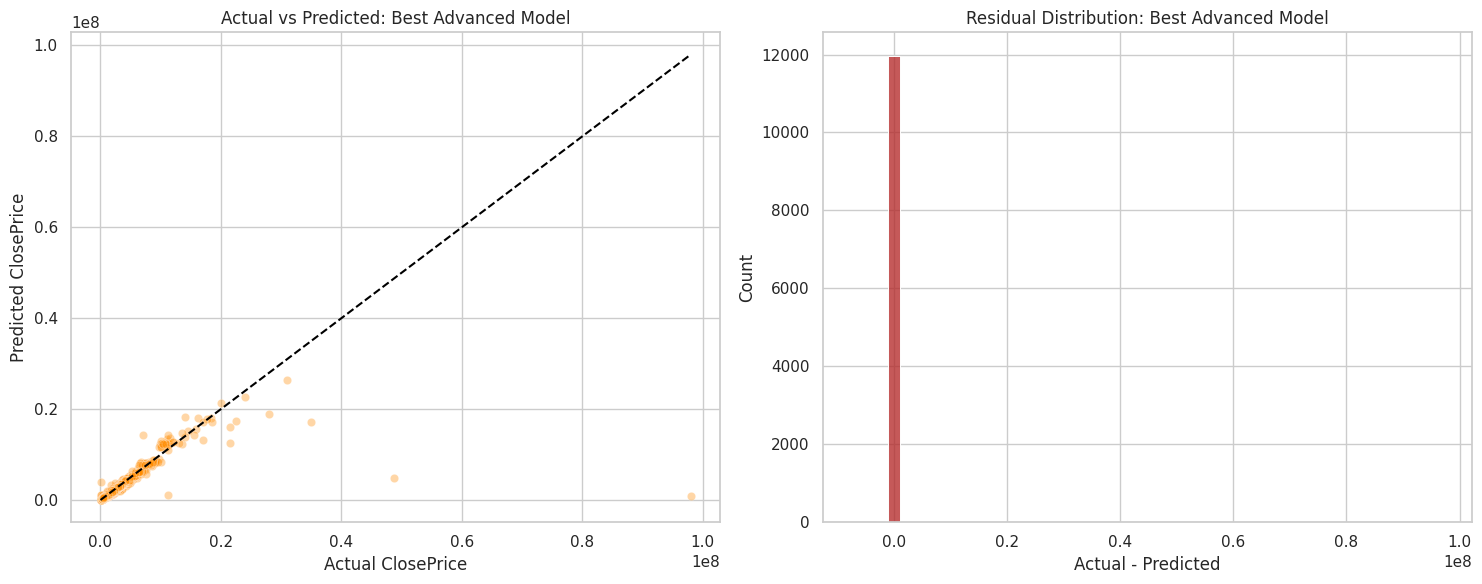

In [8]:
prediction_df = week7_predictions.copy()
prediction_df["linear_abs_error"] = prediction_df["linear_residual"].abs()
prediction_df["advanced_abs_error"] = prediction_df["advanced_residual"].abs()
prediction_df["linear_ape"] = (
    prediction_df["linear_abs_error"] / prediction_df["actual"]
)
prediction_df["advanced_ape"] = (
    prediction_df["advanced_abs_error"] / prediction_df["actual"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=prediction_df,
    x="actual",
    y="best_advanced_predicted",
    alpha=0.35,
    ax=axes[0],
    color="darkorange",
)
line_min = min(
    prediction_df["actual"].min(), prediction_df["best_advanced_predicted"].min()
)
line_max = max(
    prediction_df["actual"].max(), prediction_df["best_advanced_predicted"].max()
)
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
axes[0].set_title("Actual vs Predicted: Best Advanced Model")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")

sns.histplot(prediction_df["advanced_residual"], bins=50, ax=axes[1], color="firebrick")
axes[1].set_title("Residual Distribution: Best Advanced Model")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

,actual,best_advanced_predicted,advanced_residual,advanced_ape
10191,97972500.0000,959861.8000,97012638.1875,0.9902
8128,48720000.0000,4800050.0000,43919950.0000,0.9015
46,35000000.0000,17084574.0000,17915426.0000,0.5119
1330,11150000.0000,1086344.4000,10063655.6250,0.9026
392,28000000.0000,18971376.0000,9028624.0000,0.3225
12019,21500000.0000,12630287.0000,8869713.0000,0.4125
9888,7000000.0000,14321138.0000,-7321138.0000,1.0459
1462,21450000.0000,16045033.0000,5404967.0000,0.2520
10576,22500000.0000,17451334.0000,5048666.0000,0.2244
1727,31000000.0000,26379218.0000,4620782.0000,0.1491


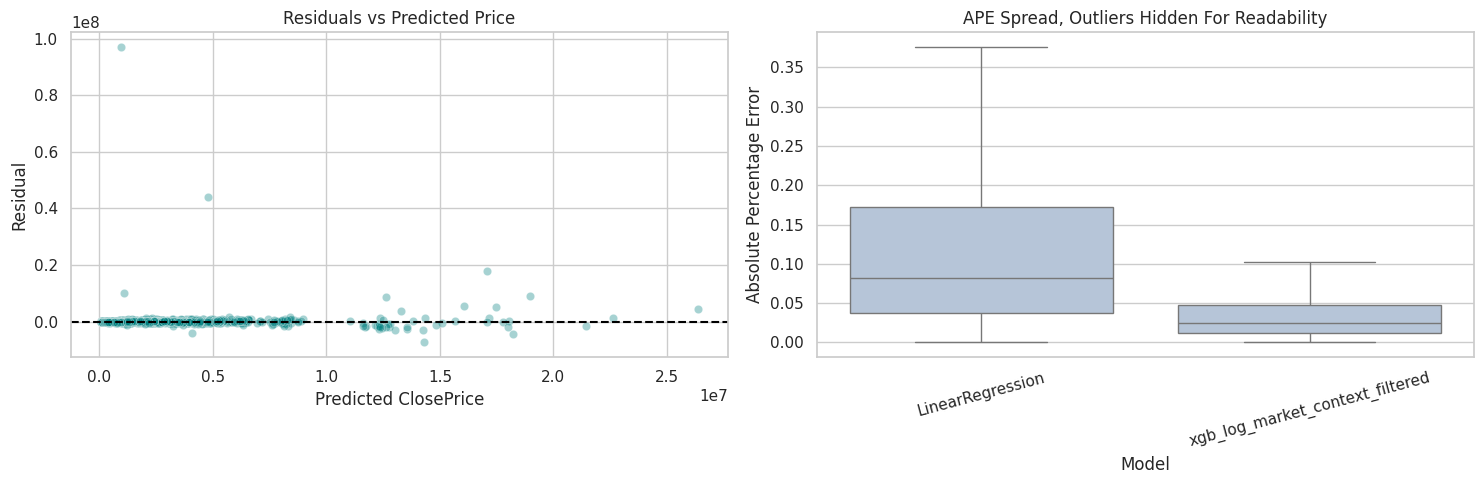

In [9]:
largest_errors = prediction_df.sort_values("advanced_abs_error", ascending=False).head(
    15
)
display(
    largest_errors[
        ["actual", "best_advanced_predicted", "advanced_residual", "advanced_ape"]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=prediction_df,
    x="best_advanced_predicted",
    y="advanced_residual",
    alpha=0.35,
    ax=axes[0],
    color="teal",
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Residuals vs Predicted Price")
axes[0].set_xlabel("Predicted ClosePrice")
axes[0].set_ylabel("Residual")

ape_plot = prediction_df[["linear_ape", "advanced_ape"]].melt(
    var_name="model", value_name="APE"
)
ape_plot["model"] = ape_plot["model"].replace(
    {"linear_ape": "LinearRegression", "advanced_ape": best_xgb["model_name"]}
)
sns.boxplot(
    data=ape_plot,
    x="model",
    y="APE",
    ax=axes[1],
    color="lightsteelblue",
    showfliers=False,
)
axes[1].set_title("APE Spread, Outliers Hidden For Readability")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Absolute Percentage Error")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Prediction Sanity Checks

The advanced model should not create unrealistic prediction ranges. This table checks whether the saved predictions include negative prices or extremely high predictions.

,model_name,min_prediction,max_prediction,predictions_under_0,predictions_over_50m
0,LinearRegression,61918.5643,31427594.0734,0,0
1,xgb_log_baseline_all,81742.9453,18564736.0000,0,0
2,xgb_log_market_context_all,72940.5312,26379218.0000,0,0
3,xgb_log_market_context_filtered,111449.8359,18026948.0000,0,0
4,xgb_log_reality_all,67936.2578,25502302.0000,0,0


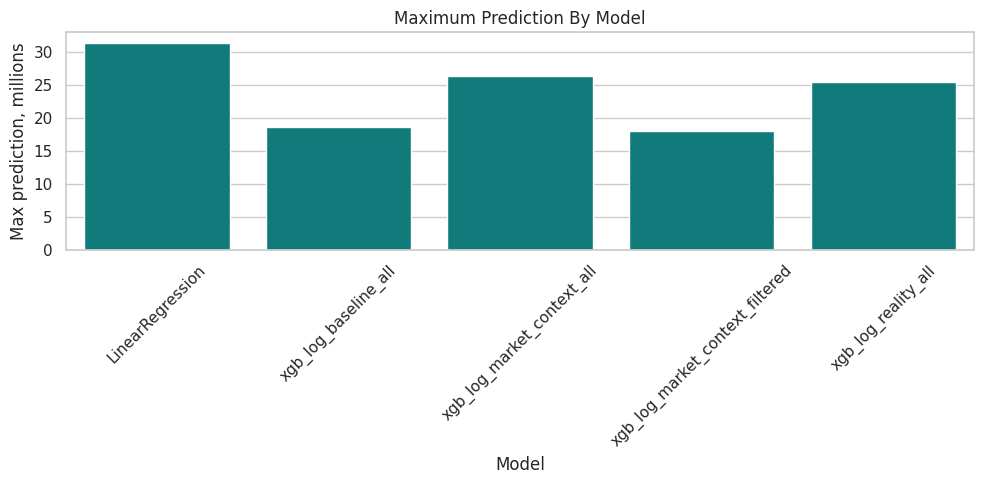

In [10]:
display(week7_sanity)

plt.figure(figsize=(10, 5))
sanity_plot = week7_sanity.copy()
sanity_plot["max_prediction_millions"] = sanity_plot["max_prediction"] / 1_000_000
sns.barplot(
    data=sanity_plot, x="model_name", y="max_prediction_millions", color="darkcyan"
)
plt.title("Maximum Prediction By Model")
plt.xlabel("Model")
plt.ylabel("Max prediction, millions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Week 8 Evaluation Insights

The main evaluation takeaway is that different metrics emphasize different model behavior.

- Linear Regression remains slightly stronger on `R2`, which means it explains overall variance well.
- The best XGBoost model has much lower `MAPE` and `MdAPE`, which means it gives more practical percentage-error performance for most homes.
- The best XGBoost model performs especially well in mainstream price bands such as `$300k-$500k`, `$500k-$1M`, and `$1M-$3M`.
- The lowest price band remains difficult because it likely contains unusual transactions or non-standard sales.
- Very high-end homes still create large dollar residuals, which is expected because ultra-luxury properties are rare and have more unique pricing factors.

For a real estate pricing workflow, this suggests that `R2` should not be the only decision metric. `MAPE`, `MdAPE`, and price-band performance are more useful for explaining how the model performs for typical properties.

## Final Week 8 Conclusion

Week 8 expands evaluation beyond a single `R2` score. The results show that Linear Regression remains a strong statistical baseline, but the best XGBoost model provides much better percentage-error performance for most homes. The price-band analysis also shows that model performance is strongest in mainstream price ranges and weakest for unusual low-price transactions and ultra-luxury edge cases.

The final `metrics_summary.csv` should be used as the main comparison table going forward.